In [ ]:
## Code to implement a ViT + Yolo model for lesion detection.


In [8]:
# Set routes for the dataset and the output directory
import pandas as pd
import numpy as np
import cv2
from pathlib import Path
import torch
from torch.utils.data import Dataset
import pydicom
import matplotlib.pyplot as plt

from mammo_prep.io import load_dicom
from mammo_prep.windowing import preprocess_window
from mammo_prep.artifacts import(
    flip_to_standard,
    crop_breast,
    resize_long_side,
    pad_to_square
)


In [16]:
class VinDrViTDataset(Dataset):

    def __init__(self, csv_path, root, split, transform=None):
        self.df = pd.read_csv(csv_path)
        self.root = Path(root)
        self.split = split
        self.transform = transform

        self.image_dir = self.root/"images"/split

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_id = row["image_id"]
        label = int(row["is_positive"])

        image_path = self.image_dir / f"{image_id}.jpg"

        image, ds = load_dicom(image_path)

        image = preprocess_window(
            image,
            dicom_dataset=ds,
            method="breast_tissue",
            voi_func="LINEAR",
            exclude_background=True,
            output_dtype=np.uint8
        )

        image = flip_to_standard(image, ds)

        image, _ = crop_breast(image)

        image = resize_long_side(
            image,
            target_size=1536
        )

        image = pad_to_square(image)

        image = cv2.resize(
            image,
            (224, 224),
            interpolation=cv2.INTER_AREA
        )

        image = image.astype(np.float32) / 255.0

        image = np.stack(
            [image, image, image],
            axis=0
        )

        image = torch.from_numpy(image)

        label = torch.tensor(
            label,
            dtype=torch.long
        )

        return image, label



In [17]:
dataset = VinDrViTDataset(
    csv_path="/home/enric_sena/Desktop/Mammo/Lesion Detection/Yolo v8/vindr_yolo_vit/vit_splits/vindr_train.csv",
    root = "/home/enric_sena/Desktop/Mammo/Lesion Detection/Yolo v8/vindr_yolo",
    split="train"
)

print("Numero de imagenes:", len(dataset))

image, label = dataset[0]

print("Tipo imagen:", type(image))
print("Shape:", image.shape)
print("Tipo label:", label.dtype)
print("Label:", label)

Numero de imagenes: 13115
Tipo imagen: <class 'torch.Tensor'>
Shape: torch.Size([3, 224, 224])
Tipo label: torch.int64
Label: tensor(1)


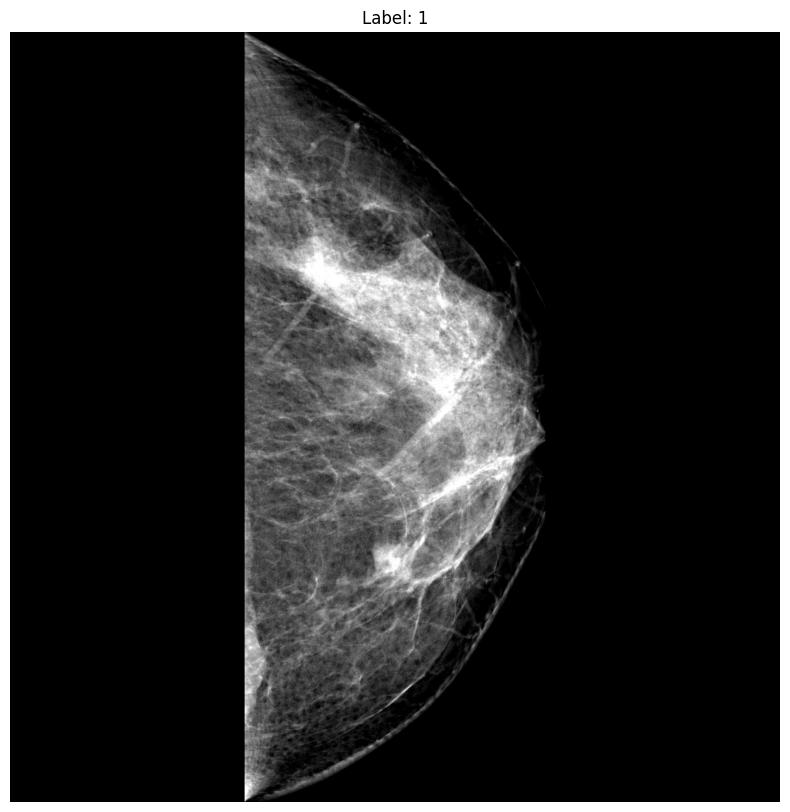

In [4]:
import matplotlib.pyplot as plt

image, label = dataset[0]

plt.figure(figsize=(10, 10))
plt.imshow(image, cmap="gray")
plt.title(f"Label: {label.item()}")
plt.axis("off")
plt.show()

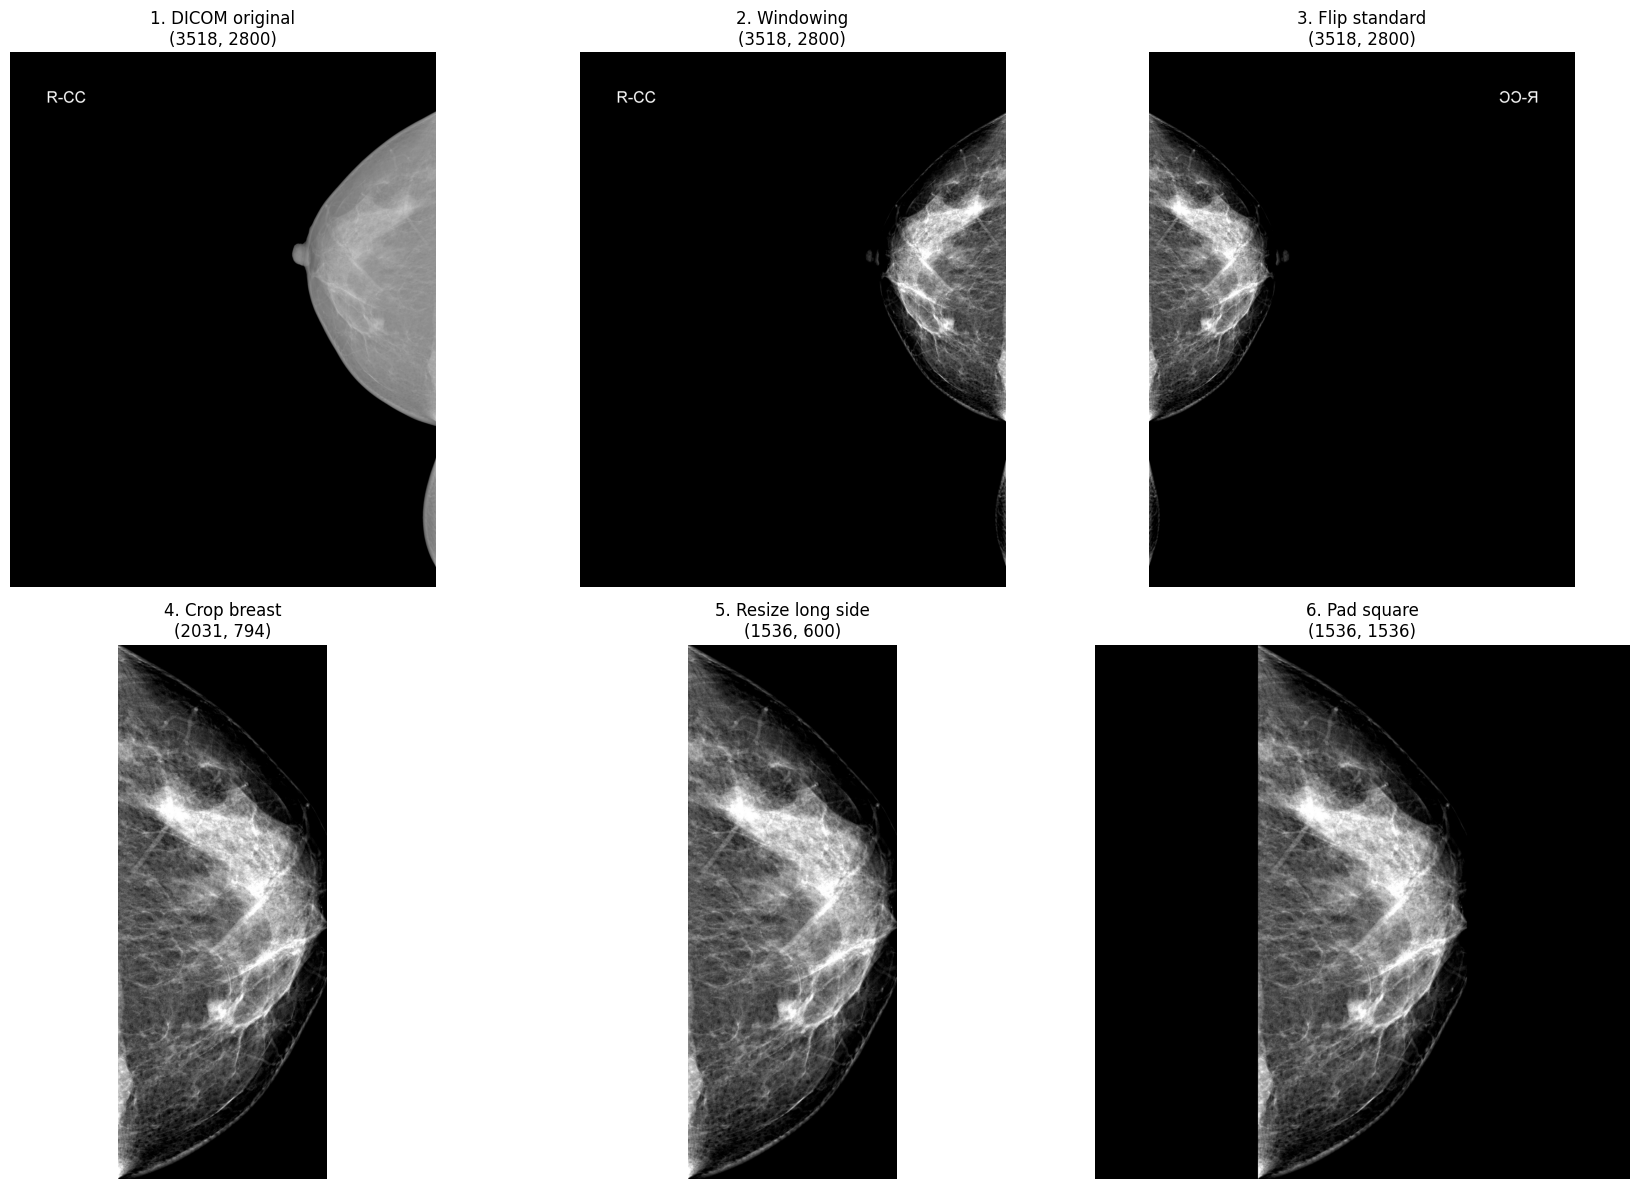

In [ ]:
# Visualize transformations


# Seleccionar una imagen
row = dataset.df.iloc[0]

image_id = row["image_id"]
image_path = dataset.image_dir / f"{image_id}.jpg"

# 1. DICOM original
original, ds = load_dicom(image_path)

# 2. Windowing
windowed = preprocess_window(
    original,
    dicom_dataset=ds,
    method="breast_tissue",
    voi_func="LINEAR",
    exclude_background=True,
    output_dtype=np.uint8
)

# 3. Orientación estándar
flipped = flip_to_standard(windowed, ds)

# 4. Crop de la mama
cropped, breast_mask = crop_breast(flipped)

# 5. Resize manteniendo proporción
resized = resize_long_side(
    cropped,
    target_size=1536
)

# 6. Padding hasta cuadrado
padded = pad_to_square(resized)


# Visualización
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

images = [
    original,
    windowed,
    flipped,
    cropped,
    resized,
    padded
]

titles = [
    f"1. DICOM original\n{original.shape}",
    f"2. Windowing\n{windowed.shape}",
    f"3. Flip standard\n{flipped.shape}",
    f"4. Crop breast\n{cropped.shape}",
    f"5. Resize long side\n{resized.shape}",
    f"6. Pad square\n{padded.shape}"
]

for ax, img, title in zip(axes.flat, images, titles):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

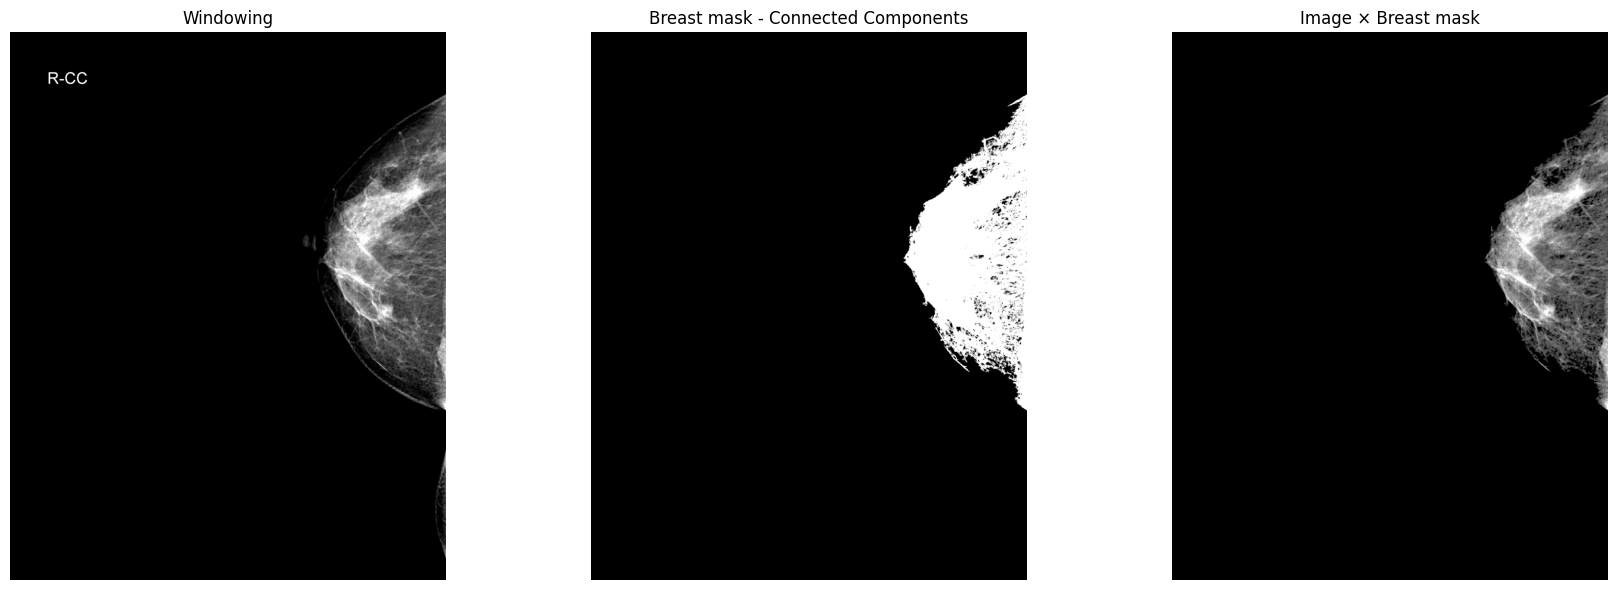

In [6]:
import matplotlib.pyplot as plt

from mammo_prep.io import load_dicom
from mammo_prep.windowing import preprocess_window
from mammo_prep.normalize import get_breast_mask


row = dataset.df.iloc[0]

image_id = row["image_id"]
image_path = dataset.image_dir / f"{image_id}.jpg"

# Cargar DICOM
image, ds = load_dicom(image_path)

# Aplicar el mismo windowing
windowed = preprocess_window(
    image,
    dicom_dataset=ds,
    method="breast_tissue",
    voi_func="LINEAR",
    exclude_background=True,
    output_dtype=np.uint8
)

# Obtener máscara mediante connected components
mask = get_breast_mask(windowed)

# Aplicar máscara visualmente
masked = np.where(mask > 0, windowed, 0)

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(windowed, cmap="gray")
axes[0].set_title("Windowing")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Breast mask - Connected Components")
axes[1].axis("off")

axes[2].imshow(masked, cmap="gray")
axes[2].set_title("Image × Breast mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()

Abans: (1536, 1536)
Després: (224, 224)


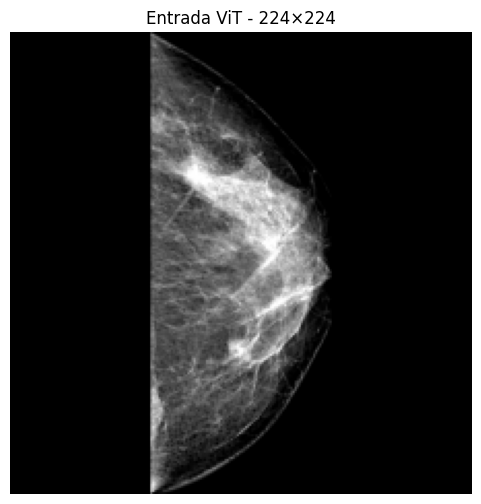

In [7]:
import cv2
import matplotlib.pyplot as plt

image_224 = cv2.resize(
    padded,
    (224, 224),
    interpolation=cv2.INTER_AREA
)

print("Abans:", padded.shape)
print("Després:", image_224.shape)

plt.figure(figsize=(6, 6))
plt.imshow(image_224, cmap="gray")
plt.title("Entrada ViT - 224×224")
plt.axis("off")
plt.show()

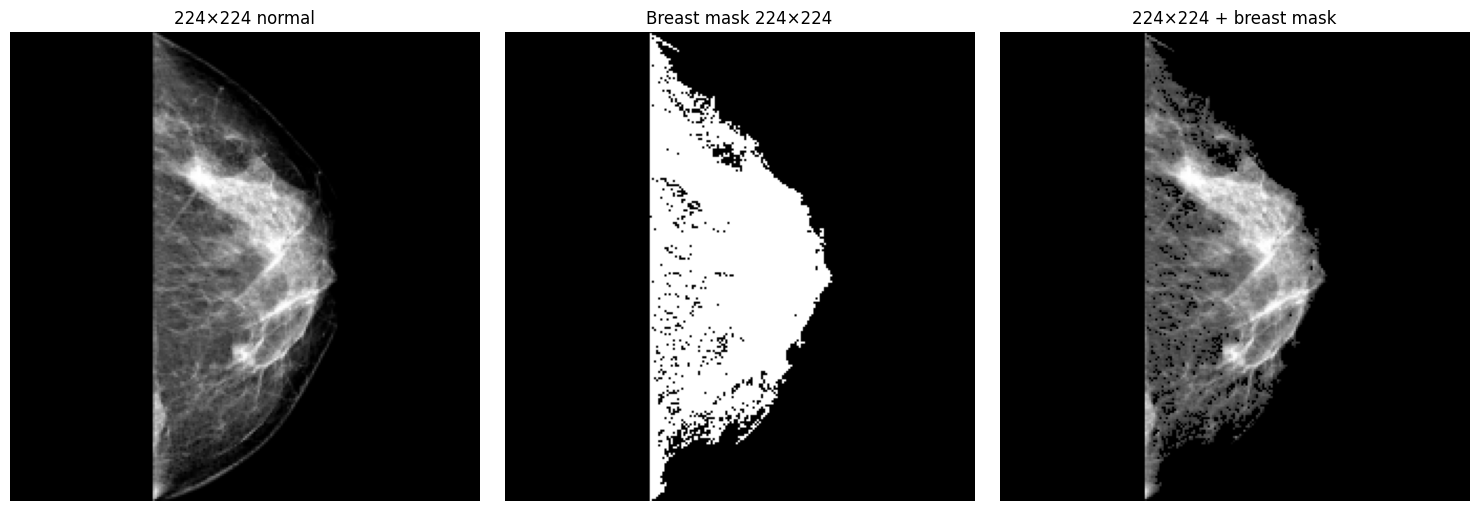

In [11]:


# 1. Resize de la imatge mantenint proporció
resized = resize_long_side(
    cropped,
    target_size=1536,
    interpolation=cv2.INTER_AREA
)

# 2. Resize de la màscara mantenint exactament la mateixa geometria
resized_mask = resize_long_side(
    breast_mask,
    target_size=1536,
    interpolation=cv2.INTER_NEAREST
)

# 3. Padding de la imatge
padded = pad_to_square(resized)

# 4. Padding de la màscara
padded_mask = pad_to_square(resized_mask)

# 5. Reducció a 224x224
image_224 = cv2.resize(
    padded,
    (224, 224),
    interpolation=cv2.INTER_AREA
)

mask_224 = cv2.resize(
    padded_mask,
    (224, 224),
    interpolation=cv2.INTER_NEAREST
)

# 6. Aplicar la màscara
image_224_masked = np.where(
    mask_224 > 0,
    image_224,
    0
)

# Visualització
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image_224, cmap="gray")
axes[0].set_title("224×224 normal")
axes[0].axis("off")

axes[1].imshow(mask_224, cmap="gray")
axes[1].set_title("Breast mask 224×224")
axes[1].axis("off")

axes[2].imshow(image_224_masked, cmap="gray")
axes[2].set_title("224×224 + breast mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()